In [ ]:
                 MOBILE REVIEWS SENTIMENT ANALYSIS

This project analyzed mobile phone customer reviews using Python and Natural Language Processing (NLP) 
techniques. The analysis classified customer reviews into positive, negative, and neutral sentiment 
categories and examined emotional patterns expressed in customer feedback.

Exploratory analysis will be  performed to investigate relationships between sentiment and important 
variables including brand, model, customer rating, review source, country, verified purchase status, 
product features, review length, and helpful votes.


In [1]:
# Import Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import string
from collections import Counter

# Sentiment analysis
from textblob import TextBlob

# Statistical analysis
from scipy.stats import chi2_contingency

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
# Load dataset

df = pd.read_csv('Mobile Reviews Sentiment.csv', encoding='utf-8', encoding_errors='ignore')

In [10]:
# Drop name and age column

df.drop(columns=['Customer_Name', 'Age'], inplace=True)

print("Customer_Name and Age columns dropped successfully.")
display(df.head())

Customer_Name and Age columns dropped successfully.


,Review_ID,Brand,Model,Price_Usd,Price_Local,Currency,Exchange_Rate_To_Usd,Rating,Review_Text,Sentiment,Country,Language,Review_Date,Verified_Purchase,Battery_Life_Rating,Camera_Rating,Performance_Rating,Design_Rating,Display_Rating,Review_Length,Word_Count,Helpful_Votes,Source
0,1,Realme,Realme 12 Pro,337.31,?27996.73,INR,83.00,2,Not worth the money spent. Wouldnt recommend.,Negative,India,Hindi,11/6/2023,True,1,1,3,2,1,46,7,1,Amazon
1,2,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4,Absolutely love this phone! The camera is next...,Positive,Brazil,Portuguese,3/30/2023,True,3,2,4,3,2,74,12,5,Flipkart
2,3,Google,Pixel 6,864.53,?71755.99,INR,83.00,4,Loving the clean UI and fast updates. Loving i...,Positive,India,Hindi,12/7/2022,True,3,5,3,2,4,55,11,8,AliExpress
3,4,Xiaomi,Redmi Note 13,660.94,?.?2425.65,AED,3.67,3,Build quality feels solid and durable. No regr...,Positive,UAE,English,3/11/2025,False,1,3,2,1,2,66,11,3,Amazon
4,5,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3,Not bad for daily use but could be optimized. ...,Neutral,Brazil,Portuguese,9/29/2023,True,3,3,2,2,1,73,12,0,BestBuy


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Review_ID             50000 non-null  int64  
 1   Customer_Name         50000 non-null  object 
 2   Age                   50000 non-null  int64  
 3   Brand                 50000 non-null  object 
 4   Model                 50000 non-null  object 
 5   Price_Usd             50000 non-null  float64
 6   Price_Local           50000 non-null  object 
 7   Currency              50000 non-null  object 
 8   Exchange_Rate_To_Usd  50000 non-null  float64
 9   Rating                50000 non-null  int64  
 10  Review_Text           50000 non-null  object 
 11  Sentiment             50000 non-null  object 
 12  Country               50000 non-null  object 
 13  Language              50000 non-null  object 
 14  Review_Date           50000 non-null  object 
 15  Verified_Purchase  

In [9]:
df.dtypes

Review_ID                 int64
Customer_Name            object
Age                       int64
Brand                    object
Model                    object
Price_Usd               float64
Price_Local              object
Currency                 object
Exchange_Rate_To_Usd    float64
Rating                    int64
Review_Text              object
Sentiment                object
Country                  object
Language                 object
Review_Date              object
Verified_Purchase          bool
Battery_Life_Rating       int64
Camera_Rating             int64
Performance_Rating        int64
Design_Rating             int64
Display_Rating            int64
Review_Length             int64
Word_Count                int64
Helpful_Votes             int64
Source                   object
dtype: object

In [11]:
df.describe()

,Review_ID,Age,Price_Usd,Exchange_Rate_To_Usd,Rating,Battery_Life_Rating,Camera_Rating,Performance_Rating,Design_Rating,Display_Rating,Review_Length,Word_Count,Helpful_Votes
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,30.075220,689.693713,12.057946,3.123120,2.71800,2.717640,2.719620,2.713960,2.721280,62.791440,10.623820,3.644180
std,14433.901067,8.931307,310.307331,26.553332,1.248612,1.34827,1.345001,1.349208,1.343346,1.352121,8.017695,1.957239,2.432745
min,1.000000,18.000000,180.020000,0.780000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,45.000000,6.000000,0.000000
25%,12500.750000,23.000000,450.792500,1.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,56.000000,9.000000,2.000000
50%,25000.500000,29.000000,637.040000,1.530000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,63.000000,11.000000,3.000000
75%,37500.250000,36.000000,900.975000,5.700000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,68.000000,12.000000,5.000000
max,50000.000000,65.000000,1499.890000,83.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,82.000000,15.000000,17.000000


In [12]:
df.shape

(50000, 25)

In [13]:
df.isnull().sum()

Review_ID               0
Customer_Name           0
Age                     0
Brand                   0
Model                   0
Price_Usd               0
Price_Local             0
Currency                0
Exchange_Rate_To_Usd    0
Rating                  0
Review_Text             0
Sentiment               0
Country                 0
Language                0
Review_Date             0
Verified_Purchase       0
Battery_Life_Rating     0
Camera_Rating           0
Performance_Rating      0
Design_Rating           0
Display_Rating          0
Review_Length           0
Word_Count              0
Helpful_Votes           0
Source                  0
dtype: int64

In [16]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
# Unique values

categorical_columns = [
    'Brand',
    'Model',
    'Currency',
    'Sentiment',
    'Country',
    'Language',
    'Verified_Purchase',
    'Source'
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].unique())


--- Brand ---
['Realme' 'Google' 'Xiaomi' 'Motorola' 'Apple' 'OnePlus' 'Samsung']

--- Model ---
['Realme 12 Pro' 'Pixel 6' 'Redmi Note 13' 'Edge 50' 'iPhone 14'
 'OnePlus 12' 'iPhone SE' 'OnePlus Nord 3' 'Mi 13 Pro' 'Moto G Power'
 'Realme Narzo 70' 'Galaxy Note 20' 'Pixel 7a' 'Razr 40' 'Poco X6'
 'iPhone 15 Pro' 'Pixel 8' 'iPhone 13' 'Galaxy S24' 'Galaxy A55'
 'OnePlus 11R' 'Galaxy Z Flip']

--- Currency ---
['INR' 'BRL' 'AED' 'AUD' 'EUR' 'GBP' 'CAD' 'USD']

--- Sentiment ---
['Negative' 'Positive' 'Neutral']

--- Country ---
['India' 'Brazil' 'UAE' 'Australia' 'Germany' 'UK' 'Canada' 'USA']

--- Language ---
['Hindi' 'Portuguese' 'English' 'German']

--- Verified_Purchase ---
[ True False]

--- Source ---
['Amazon' 'Flipkart' 'AliExpress' 'BestBuy' 'eBay']


In [19]:
# Convert numerical columns to numeric format and convert the review date to datetime.

numeric_columns = [
    'Age',
    'Price_Usd',
    'Exchange_Rate_To_Usd',
    'Rating',
    'Battery_Life_Rating',
    'Camera_Rating',
    'Performance_Rating',
    'Design_Rating',
    'Display_Rating',
    'Review_Length',
    'Word_Count',
    'Helpful_Votes'
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

df['Review_Date'] = pd.to_datetime(df['Review_Date'], errors='coerce')

print("Data types converted successfully.")

Data types converted successfully.


In [14]:
#Clean review text

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Clean_Review_Text'] = df['Review_Text'].apply(clean_text)

display(df[['Review_Text', 'Clean_Review_Text']].head(5))

,Review_Text,Clean_Review_Text
0,Not worth the money spent. Wouldnt recommend.,not worth the money spent wouldnt recommend
1,Absolutely love this phone! The camera is next...,absolutely love this phone the camera is next ...
2,Loving the clean UI and fast updates. Loving i...,loving the clean ui and fast updates loving it...
3,Build quality feels solid and durable. No regr...,build quality feels solid and durable no regre...
4,Not bad for daily use but could be optimized. ...,not bad for daily use but could be optimized a...


In [30]:
# Helpful reviews

top_helpful_reviews = df.sort_values(
    'Helpful_Votes',
    ascending=False
)[[
    'Brand',
    'Model',
    'Rating',
    'Sentiment',
    'Helpful_Votes',
    'Review_Text'
]].head(10)

display(top_helpful_reviews)

,Brand,Model,Rating,Sentiment,Helpful_Votes,Review_Text
29766,Motorola,Razr 40,5,Positive,17,Fast charging is a lifesaver. Loving it so far!
15507,Realme,Realme Narzo 70,4,Positive,16,Build quality feels solid and durable. No regr...
26135,OnePlus,OnePlus 12,2,Positive,16,"Face unlock is instant, super smooth. No regre..."
2247,Apple,iPhone 14,4,Positive,15,Build quality feels solid and durable. Absolut...
29620,Samsung,Galaxy Note 20,4,Positive,15,Worth every penny. Highly recommended! No regr...
33052,Realme,Realme Narzo 70,4,Positive,15,Display is crisp and vibrant perfect for gami...
12273,OnePlus,OnePlus 12,4,Positive,15,Battery easily lasts a day with heavy use. Bes...
2866,Apple,iPhone 13,2,Positive,15,Loving the clean UI and fast updates. Best pur...
10019,Samsung,Galaxy Note 20,3,Positive,15,Smooth performance even after months of use. A...
35040,Realme,Realme 12 Pro,4,Positive,15,"Face unlock is instant, super smooth. Best pur..."


Sentiment
Positive    27540
Neutral     12549
Negative     9911
Name: count, dtype: int64


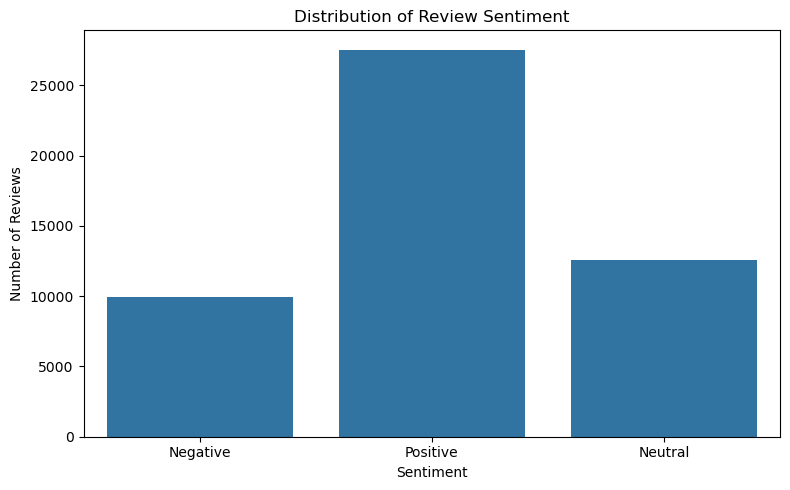

In [22]:
# Sentiment distribution
# Analyze and visualize the distribution of positive, negative, and neutral reviews.

sentiment_counts = df['Sentiment'].value_counts()

print(sentiment_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sentiment')
plt.title('Distribution of Review Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [ ]:
The positive sentiment has the highest number of reviews.

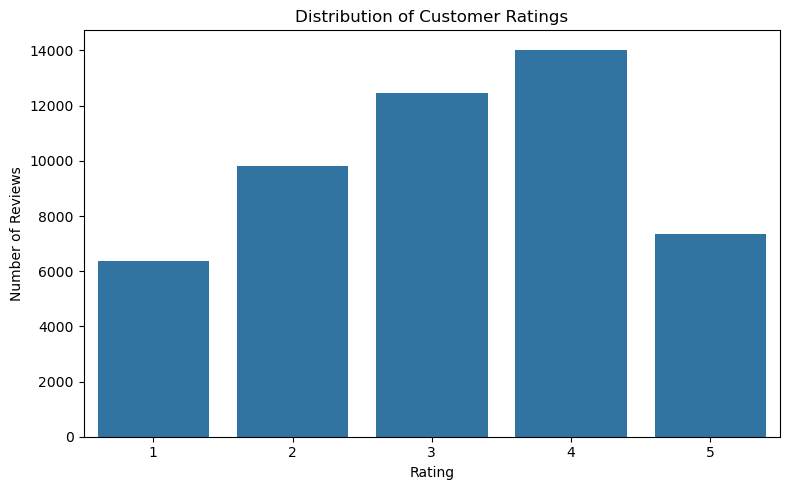

In [23]:
# Rating distribution

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Rating')
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [ ]:
4 stars is the most frequent rating, peaking with the highest number of reviews.

Sentiment,Negative,Neutral,Positive
Rating,,,
1,78.53,21.06,0.41
2,39.24,52.24,8.52
3,7.98,38.36,53.66
4,0.44,8.75,90.80
5,0.00,1.12,98.88


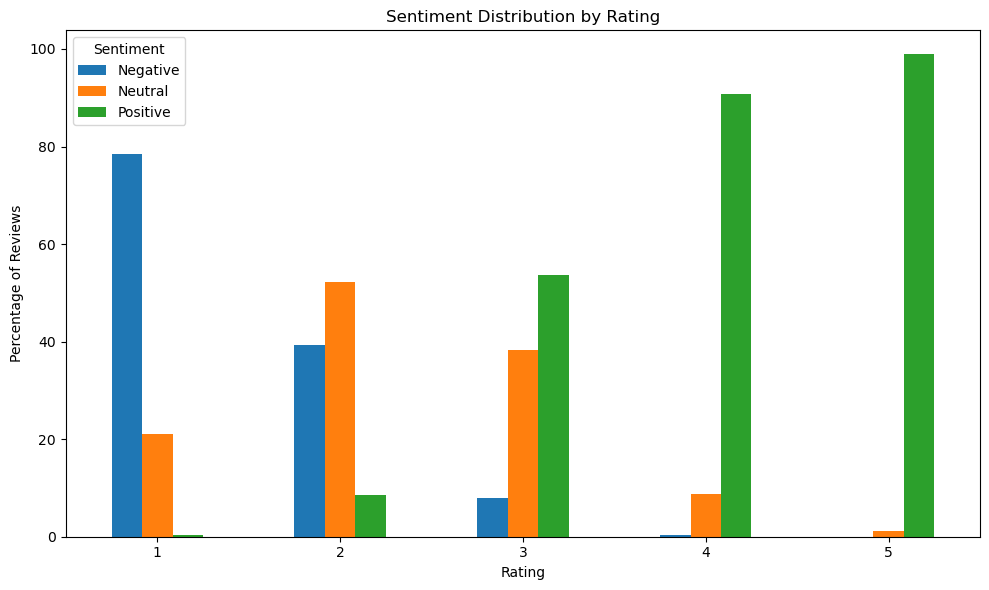

In [24]:
# Examine the relationship between sentiment and customer rating

sentiment_rating = pd.crosstab(
    df['Rating'],
    df['Sentiment'],
    normalize='index'
) * 100

display(sentiment_rating.round(2))

sentiment_rating.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sentiment Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

Sentiment,Negative,Neutral,Positive
Brand,,,
Apple,20.03,24.69,55.28
Google,19.12,25.60,55.28
Motorola,19.50,26.29,54.21
OnePlus,20.10,24.43,55.48
Realme,19.83,24.47,55.71
Samsung,19.88,25.21,54.91
Xiaomi,20.30,25.01,54.69


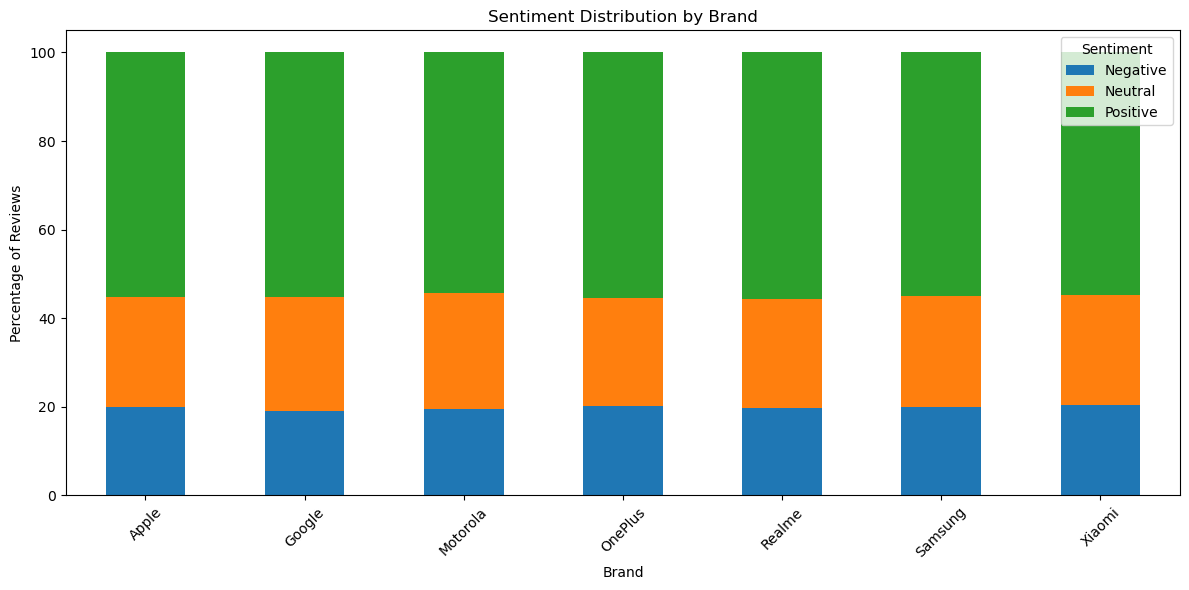

In [25]:
# Sentiment by brand

brand_sentiment = pd.crosstab(
    df['Brand'],
    df['Sentiment'],
    normalize='index'
) * 100

display(brand_sentiment.round(2))

brand_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Sentiment Distribution by Brand')
plt.xlabel('Brand')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

Brand
Realme      3.14
Apple       3.13
OnePlus     3.13
Google      3.12
Motorola    3.11
Samsung     3.11
Xiaomi      3.11
Name: Rating, dtype: float64

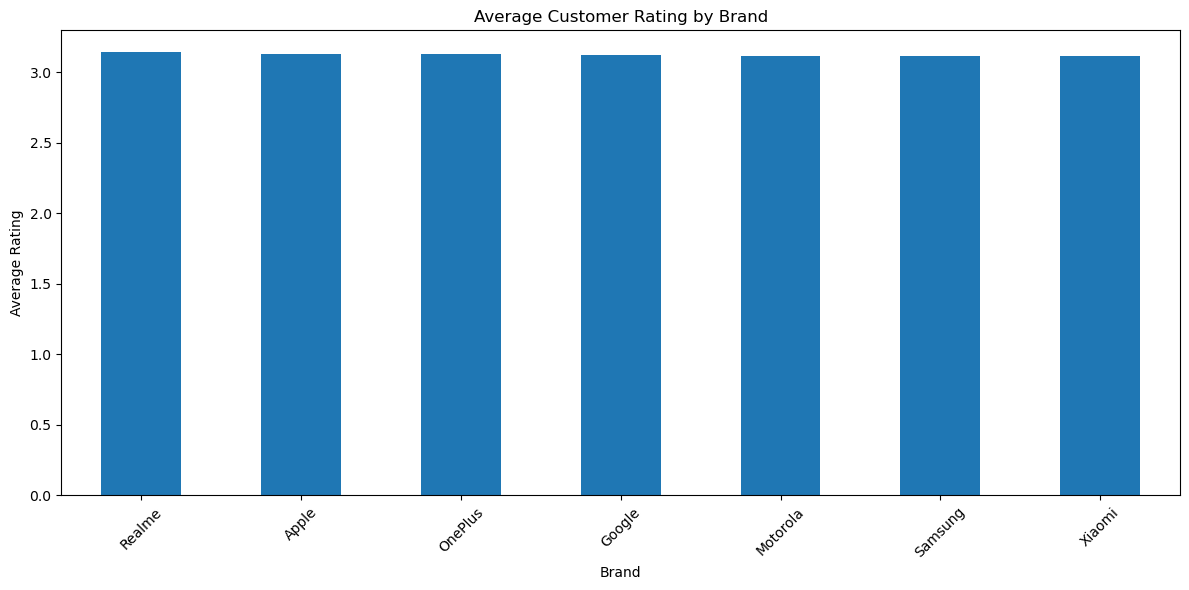

In [26]:
# Average brand rating

average_brand_rating = (
    df.groupby('Brand')['Rating']
    .mean()
    .sort_values(ascending=False)
)

display(average_brand_rating.round(2))

plt.figure(figsize=(12, 6))
average_brand_rating.plot(kind='bar')

plt.title('Average Customer Rating by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
# Identify sentiment patterns across individual mobile phone models.

model_sentiment = pd.crosstab(
    df['Model'],
    df['Sentiment'],
    normalize='index'
) * 100

display(model_sentiment.round(2))

Sentiment,Negative,Neutral,Positive
Model,,,
Edge 50,19.48,26.39,54.13
Galaxy A55,21.03,24.27,54.70
Galaxy Note 20,19.34,25.27,55.39
Galaxy S24,19.99,26.01,54.00
Galaxy Z Flip,19.14,25.32,55.54
Mi 13 Pro,20.25,24.74,55.01
Moto G Power,18.63,25.82,55.55
OnePlus 11R,20.35,24.70,54.95
OnePlus 12,20.45,24.41,55.14


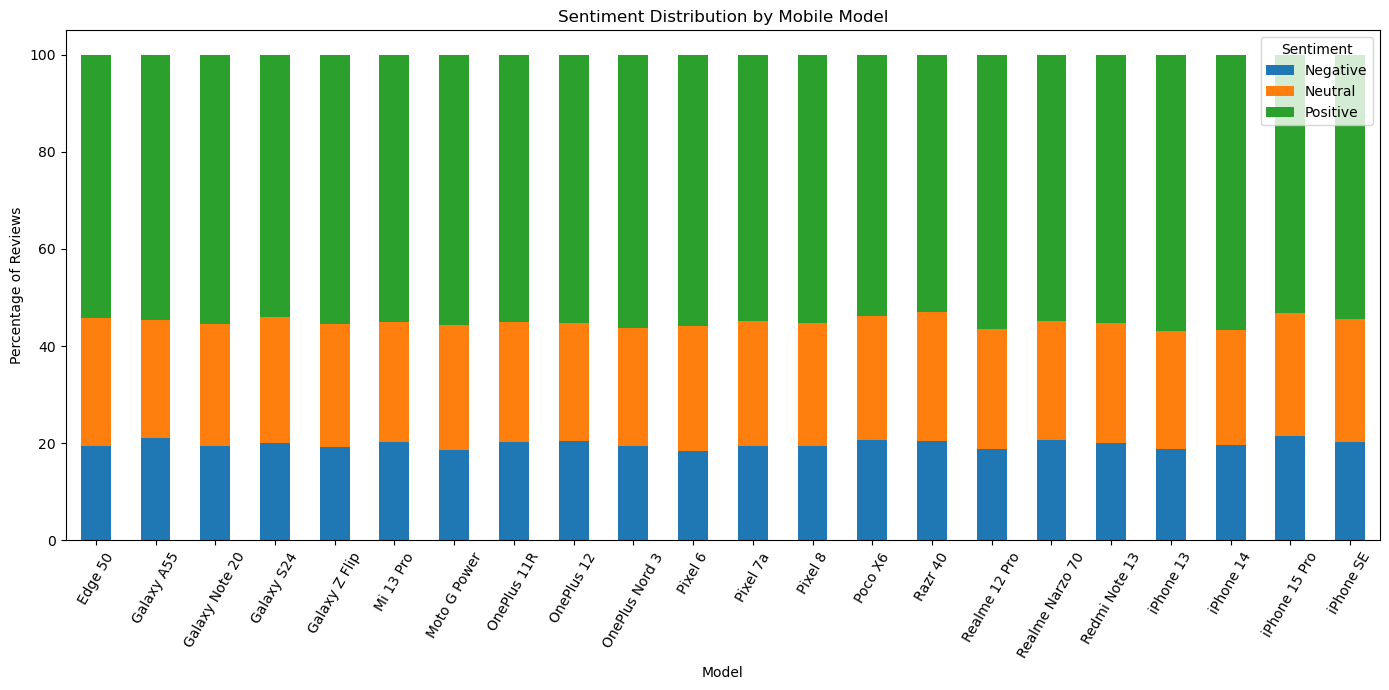

In [28]:
# Visualization

model_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('Sentiment Distribution by Mobile Model')
plt.xlabel('Model')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=60)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

Sentiment,Negative,Neutral,Positive
Source,,,
AliExpress,19.41,24.49,56.10
Amazon,19.82,25.33,54.84
BestBuy,19.93,24.84,55.24
Flipkart,20.16,25.06,54.78
eBay,19.79,25.77,54.45


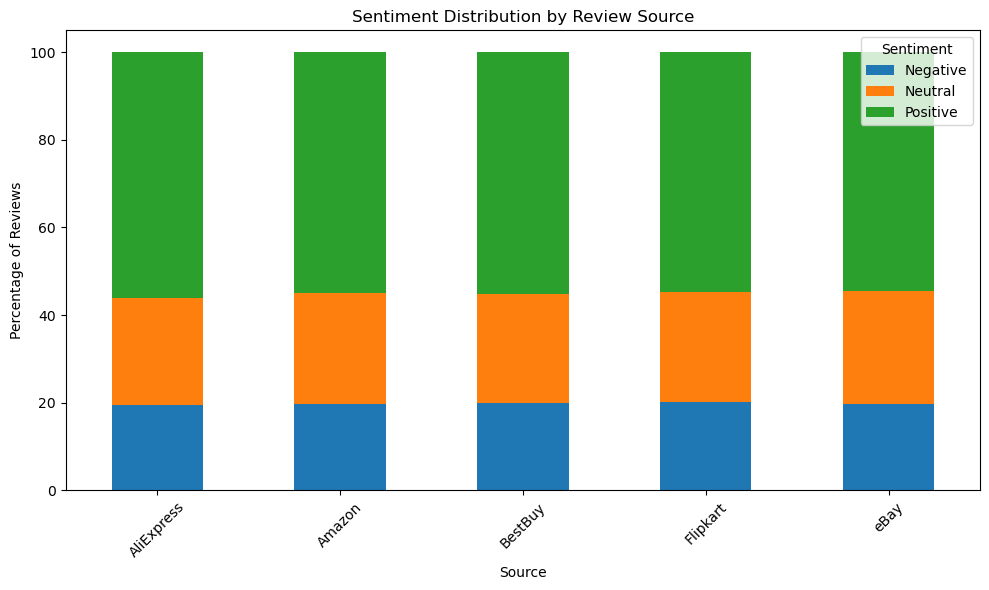

In [29]:
# Identify sentiment by source

source_sentiment = pd.crosstab(
    df['Source'],
    df['Sentiment'],
    normalize='index'
) * 100

display(source_sentiment.round(2))

source_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Sentiment Distribution by Review Source')
plt.xlabel('Source')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [30]:
# Sentiment by Country

country_sentiment = pd.crosstab(
    df['Country'],
    df['Sentiment'],
    normalize='index'
) * 100

display(country_sentiment.round(2))

Sentiment,Negative,Neutral,Positive
Country,,,
Australia,19.63,25.04,55.33
Brazil,19.33,26.50,54.17
Canada,20.06,24.54,55.40
Germany,20.53,24.96,54.51
India,19.97,25.34,54.69
UAE,19.04,25.24,55.73
UK,19.94,24.12,55.94
USA,20.09,25.00,54.90


Sentiment,Negative,Neutral,Positive
Verified_Purchase,,,
False,19.65,24.98,55.37
True,19.87,25.13,55.01


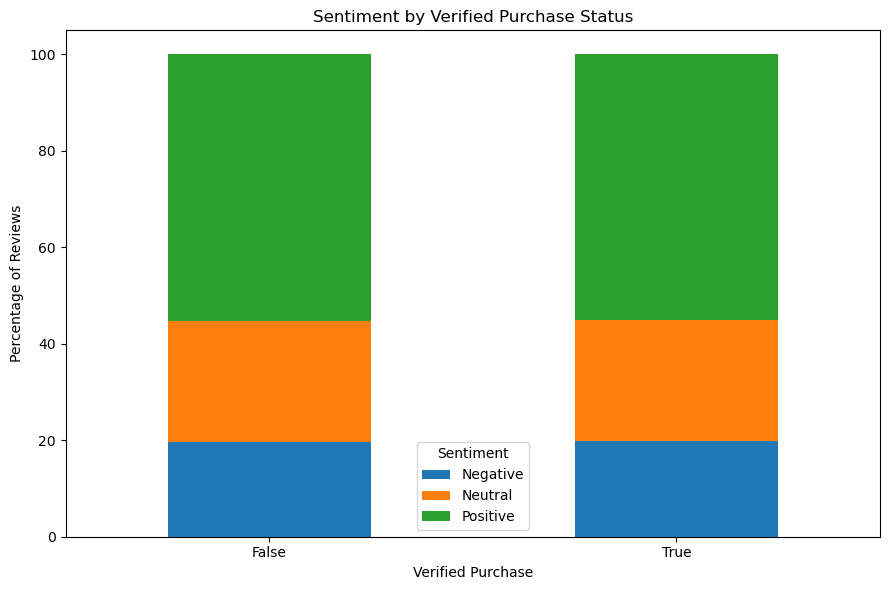

In [32]:
# Verified Purchase vs Sentiment

verified_sentiment = pd.crosstab(
    df['Verified_Purchase'],
    df['Sentiment'],
    normalize='index'
) * 100

display(verified_sentiment.round(2))

verified_sentiment.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 6)
)

plt.title('Sentiment by Verified Purchase Status')
plt.xlabel('Verified Purchase')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [ ]:
Verification status does not influence customer sentiment.

Display_Rating         2.72
Performance_Rating     2.72
Battery_Life_Rating    2.72
Camera_Rating          2.72
Design_Rating          2.71
dtype: float64

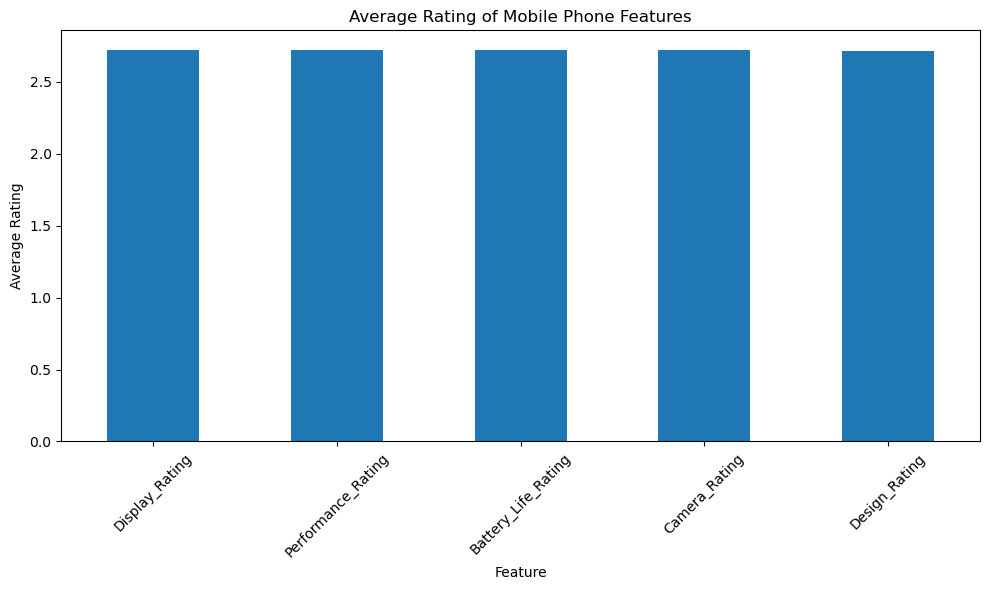

In [33]:
feature_columns = [
    'Battery_Life_Rating',
    'Camera_Rating',
    'Performance_Rating',
    'Design_Rating',
    'Display_Rating'
]

feature_means = df[feature_columns].mean().sort_values(ascending=False)

display(feature_means.round(2))

plt.figure(figsize=(10, 6))
feature_means.plot(kind='bar')

plt.title('Average Rating of Mobile Phone Features')
plt.xlabel('Feature')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Battery_Life_Rating,Camera_Rating,Performance_Rating,Design_Rating,Display_Rating
Sentiment,,,,,
Negative,1.52,1.52,1.53,1.52,1.53
Neutral,2.13,2.15,2.14,2.15,2.14
Positive,3.42,3.41,3.41,3.40,3.42


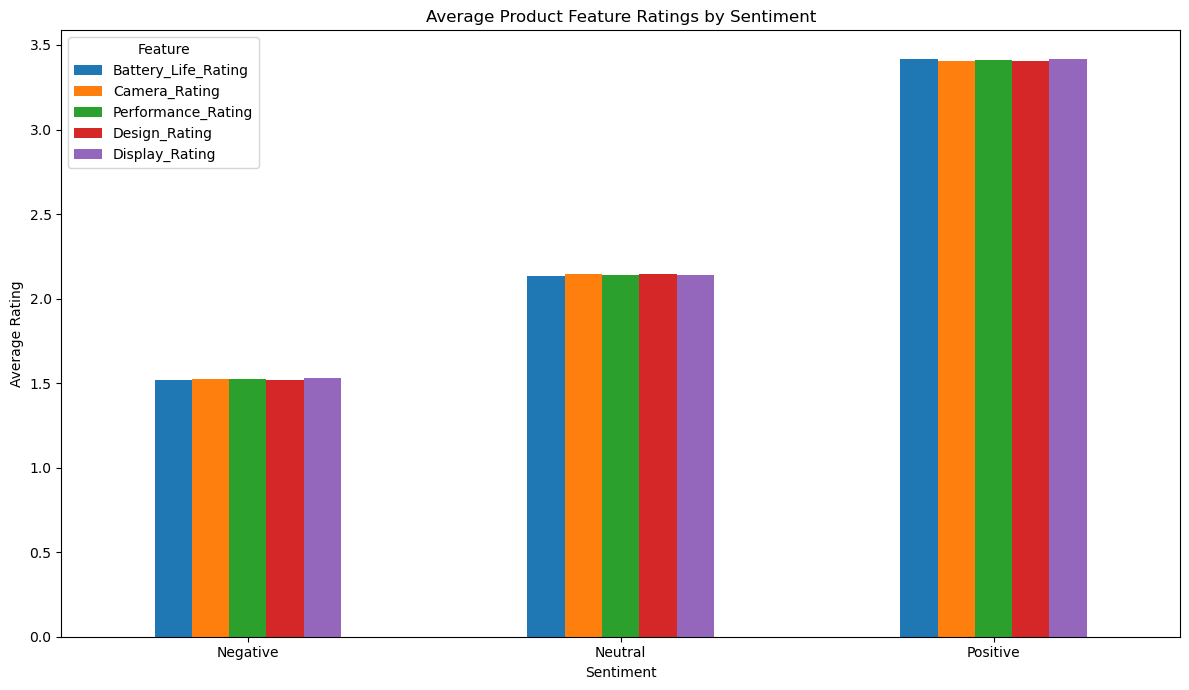

In [34]:
# Product feature rating by sentiment

feature_by_sentiment = df.groupby('Sentiment')[feature_columns].mean()

display(feature_by_sentiment.round(2))

feature_by_sentiment.plot(
    kind='bar',
    figsize=(12, 7)
)

plt.title('Average Product Feature Ratings by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.legend(title='Feature')
plt.tight_layout()
plt.show()

In [35]:
# NLP sentiment analysis

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

df['Polarity'] = df['Clean_Review_Text'].apply(get_polarity)

def classify_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['NLP_Sentiment'] = df['Polarity'].apply(classify_sentiment)

display(
    df[['Review_Text', 'Polarity', 'NLP_Sentiment']].head(10)
)

,Review_Text,Polarity,NLP_Sentiment
0,Not worth the money spent. Wouldnt recommend.,-0.125000,Negative
1,Absolutely love this phone! The camera is next...,0.266667,Positive
2,Loving the clean UI and fast updates. Loving i...,0.373333,Positive
3,Build quality feels solid and durable. No regr...,0.025000,Positive
4,Not bad for daily use but could be optimized. ...,0.050000,Positive
5,Battery easily lasts a day with heavy use. No ...,0.094444,Positive
6,Loving the clean UI and fast updates. Absolute...,0.366667,Positive
7,"Phone hangs often, regret buying it. Wouldnt r...",0.000000,Neutral
8,Battery easily lasts a day with heavy use. Lov...,0.233333,Positive
9,Smooth performance even after months of use. N...,0.225000,Positive


In [36]:
comparison = pd.crosstab(
    df['Sentiment'],
    df['NLP_Sentiment']
)

display(comparison)

NLP_Sentiment,Negative,Neutral,Positive
Sentiment,,,
Negative,6983,1458,1470
Neutral,839,456,11254
Positive,0,0,27540


In [37]:
comparison_percentage = pd.crosstab(
    df['Sentiment'],
    df['NLP_Sentiment'],
    normalize='index'
) * 100

display(comparison_percentage.round(2))

NLP_Sentiment,Negative,Neutral,Positive
Sentiment,,,
Negative,70.46,14.71,14.83
Neutral,6.69,3.63,89.68
Positive,0.00,0.00,100.00


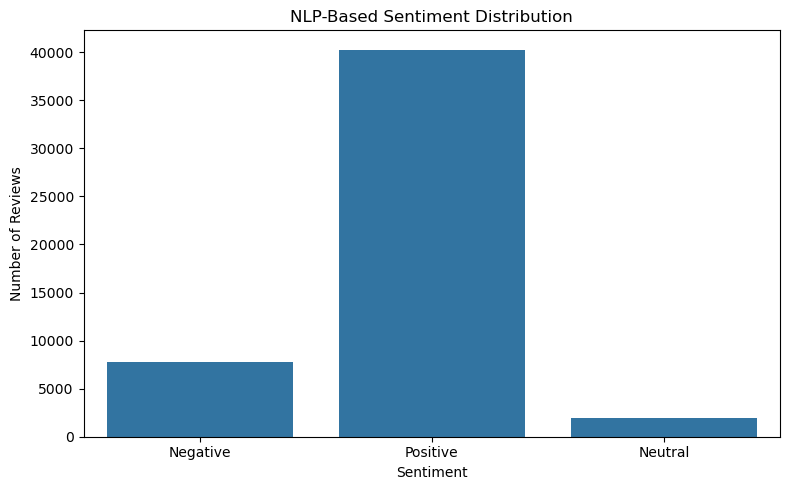

In [38]:
# Visualize the sentiment classifications generated by the NLP model.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='NLP_Sentiment'
)

plt.title('NLP-Based Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

Sentiment
Neutral     66.45
Positive    63.58
Negative    55.96
Name: Review_Length, dtype: float64

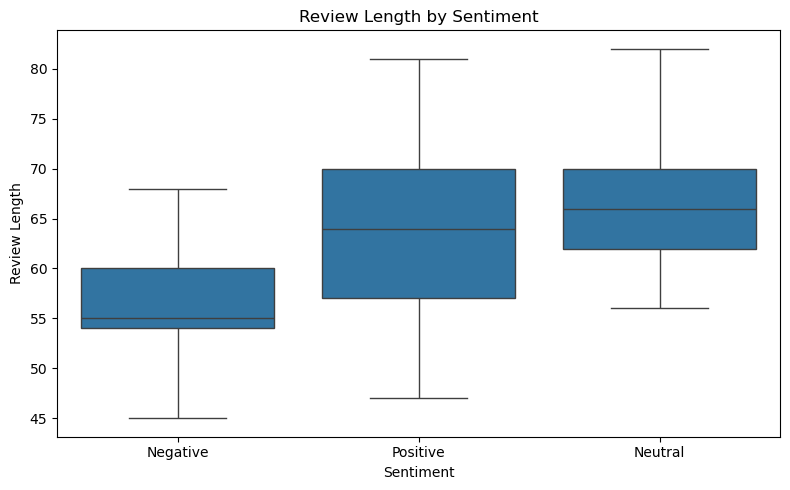

In [64]:
# Review length by sentiment

review_length_sentiment = (
    df.groupby('Sentiment')['Review_Length']
    .mean()
    .sort_values(ascending=False)
)

display(review_length_sentiment.round(2))

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Sentiment',
    y='Review_Length'
)

plt.title('Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Review Length')
plt.tight_layout()
plt.show()

In [ ]:
There is a clear upward trend showing that positive and neutral reviewers tend to be longer than negative
reviewers.

Sentiment
Negative     8.86
Neutral     11.31
Positive    10.95
Name: Word_Count, dtype: float64

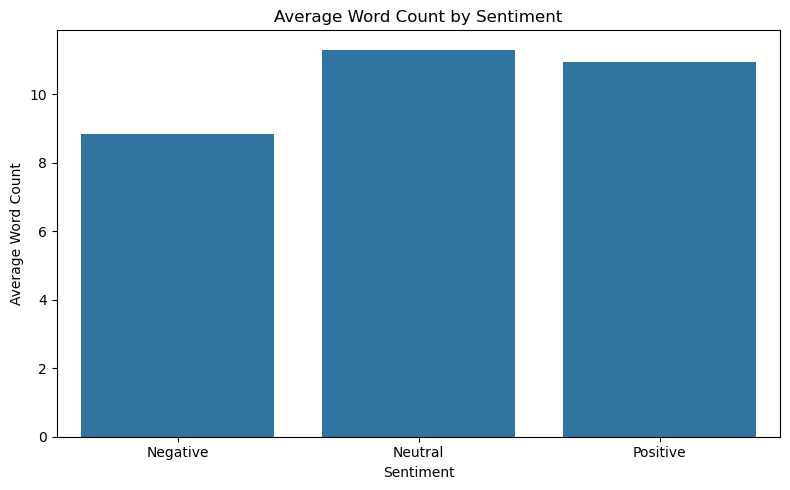

In [4]:
# Compare the average number of words used in positive, negative, and neutral reviews.

word_count_sentiment = (
    df.groupby('Sentiment')['Word_Count']
    .mean()
)

display(word_count_sentiment.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=word_count_sentiment.index,
    y=word_count_sentiment.values
)

plt.title('Average Word Count by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Word Count')
plt.tight_layout()
plt.show()

Sentiment
Positive    5.00
Negative    1.98
Neutral     1.98
Name: Helpful_Votes, dtype: float64

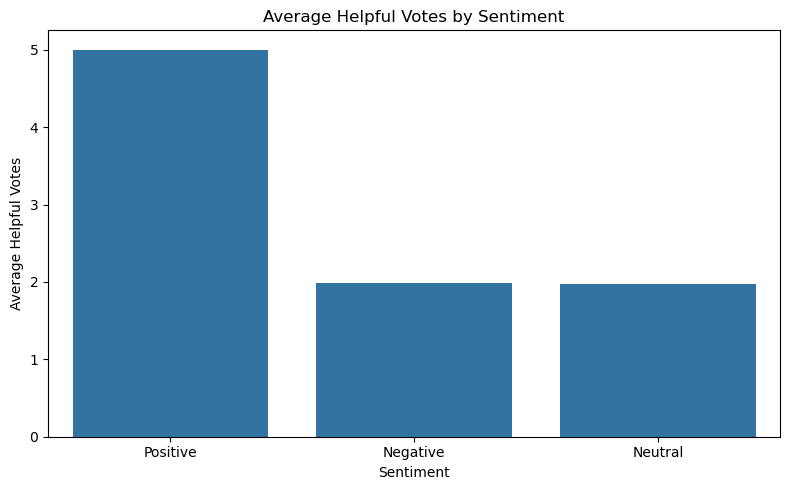

In [5]:
# Determine whether reviews with different sentiments receive different numbers of helpful votes.

helpful_sentiment = (
    df.groupby('Sentiment')['Helpful_Votes']
    .mean()
    .sort_values(ascending=False)
)

display(helpful_sentiment.round(2))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=helpful_sentiment.index,
    y=helpful_sentiment.values
)

plt.title('Average Helpful Votes by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Helpful Votes')
plt.tight_layout()
plt.show()

In [7]:
# Analyze sentiment patterns across different languages.

language_sentiment = pd.crosstab(
    df['Language'],
    df['Sentiment'],
    normalize='index'
) * 100

display(language_sentiment.round(2))

Sentiment,Negative,Neutral,Positive
Language,,,
English,19.75,24.79,55.46
German,20.53,24.96,54.51
Hindi,19.97,25.34,54.69
Portuguese,19.33,26.50,54.17


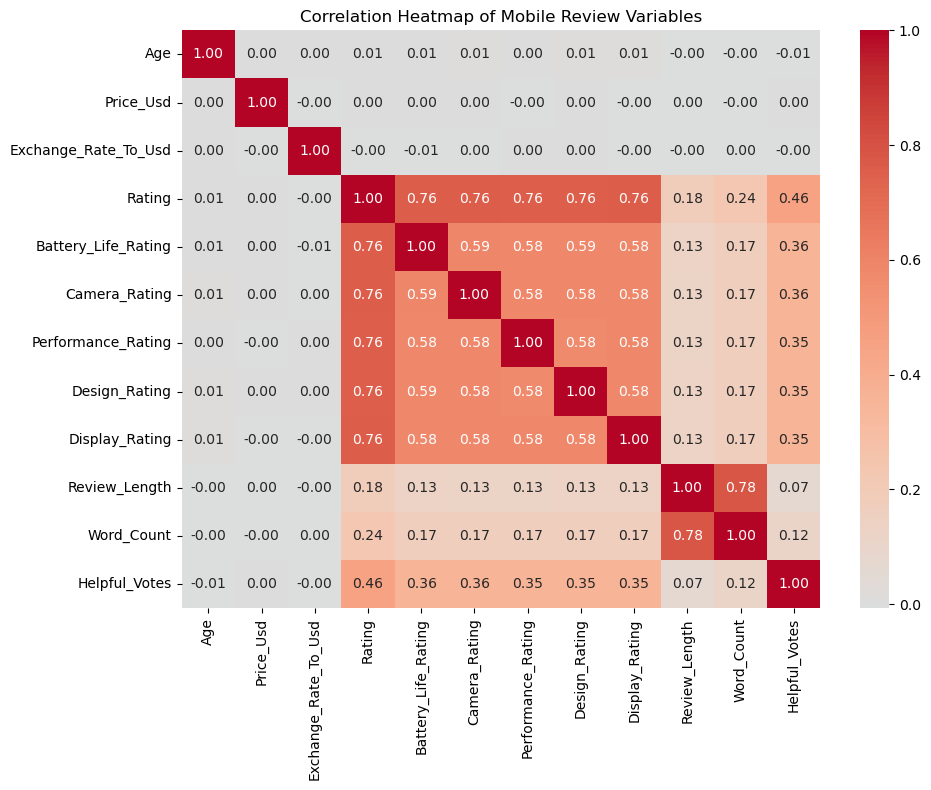

In [24]:
# Plot correlation heatmap

correlation_columns = [
    'Age',
    'Price_Usd',
    'Exchange_Rate_To_Usd',
    'Rating',
    'Battery_Life_Rating',
    'Camera_Rating',
    'Performance_Rating',
    'Design_Rating',
    'Display_Rating',
    'Review_Length',
    'Word_Count',
    'Helpful_Votes',
   
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
      fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Mobile Review Variables')
plt.tight_layout()
plt.show()

In [ ]:
### Correlation Heatmap – Key Findings

1. Rating and product feature ratings: Overall Rating has a strong positive correlation of approximately
0.76 with Battery_Life_Rating, Camera_Rating, Performance_Rating, Design_Rating, and 
Display_Rating. This indicates that higher ratings across individual product features are strongly 
associated with higher overall customer ratings.

2. Relationships among product features: The individual feature ratings have moderate positive correlations,
generally between 0.58 and 0.59. This suggests that customers who rate one aspect of a mobile phone highly
tend to rate other aspects positively as well.

3. Review Length and Word Count: Review_Length and Word_Count have a strong positive correlation of 
approximately 0.78. This is expected because longer reviews generally contain more words.

4. Rating and Helpful Votes: Rating has a moderate positive correlation of approximately 0.46 with
Helpful_Votes. This suggests that reviews with higher ratings tend to receive more helpful votes, although
the relationship is not very strong.

5. Helpful Votes and Product Feature Ratings: Helpful_Votes has moderate positive correlations with the
individual feature ratings, ranging from approximately 0.35 to 0.36.

6. Price and other variables: Price_Usd shows correlations close to 0.00 with most variables in the 
dataset. This indicates little to no linear relationship between mobile phone price and the other numerical 
variables analyzed.

7. Exchange Rate: Exchange_Rate_To_Usd also shows correlations close to zero with most variables, 
suggesting that exchange-rate variation does not have a meaningful linear relationship with customer ratings
or review characteristics in this dataset.



In [12]:
# Statistical Test
# Use a chi-square test to determine whether verified purchase status and sentiment are significantly associated.

contingency_table = pd.crosstab(
    df['Verified_Purchase'],
    df['Sentiment']
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", round(chi2, 4))
print("P-value:", round(p_value, 6))
print("Degrees of freedom:", degrees_of_freedom)

if p_value < 0.05:
    print("Result: There is a statistically significant association between verified purchase status and sentiment.")
else:
    print("Result: There is no statistically significant association between verified purchase status and sentiment.")

Chi-square statistic: 0.4395
P-value: 0.802731
Degrees of freedom: 2
Result: There is no statistically significant association between verified purchase status and sentiment.


In [31]:
# Identify the most frequently occurring words in mobile phone reviews.

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words='english',
    max_features=30
)

word_matrix = vectorizer.fit_transform(
    df['Clean_Review_Text']
)

word_counts = np.asarray(
    word_matrix.sum(axis=0)
).flatten()

word_frequency = pd.DataFrame({
    'Word': vectorizer.get_feature_names_out(),
    'Frequency': word_counts
}).sort_values(
    'Frequency',
    ascending=False
)

display(word_frequency)

,Word,Frequency
27,use,11148
28,worth,10640
17,loving,9754
0,absolutely,9556
3,best,8103
18,okay,7946
5,buying,7824
12,far,7004
22,purchase,6869
29,year,6869


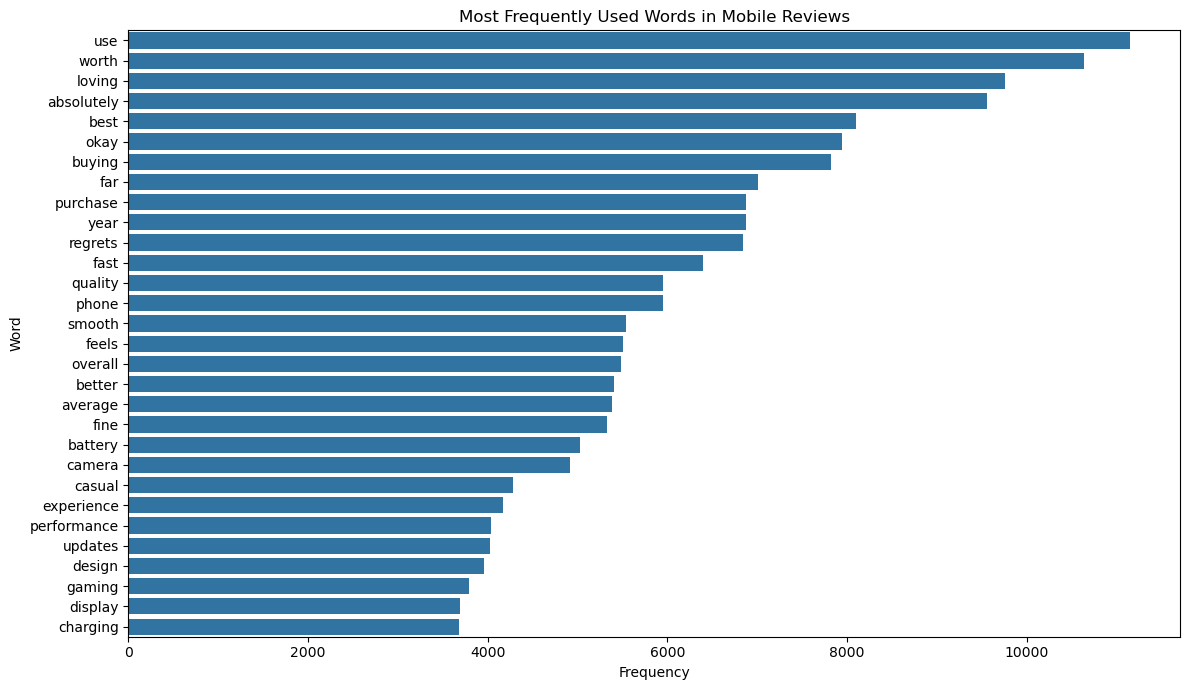

In [16]:
# Visualize frequent words

plt.figure(figsize=(12, 7))

sns.barplot(
    data=word_frequency,
    x='Frequency',
    y='Word'
)

plt.title('Most Frequently Used Words in Mobile Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

In [23]:
# Identify the most frequently used words in positive and negative reviews.

positive_reviews = df.loc[
    df['Sentiment'].str.lower() == 'positive',
    'Clean_Review_Text'
]

negative_reviews = df.loc[
    df['Sentiment'].str.lower() == 'negative',
    'Clean_Review_Text'
    ] 

def get_top_words(texts, n=10):
    vectorizer = CountVectorizer(stop_words='english', max_features=n)
    matrix = vectorizer.fit_transform(texts)
    counts = np.asarray(matrix.sum(axis=0)).flatten()

    result = pd.DataFrame({
        'Words': vectorizer.get_feature_names_out(),
        'Frequency': counts
    })
    return result.sort_values('Frequency', ascending=False)
 
positive_words = get_top_words(positive_reviews)
negative_words = get_top_words(negative_reviews)

print("Top Positive Review Words:")
display(positive_words)

print("Top Negative Review Words:")
display(negative_words)
                                 

Top Positive Review Words:


,Words,Frequency
4,loving,9754
8,worth,9615
0,absolutely,9556
3,far,7004
1,best,6869
5,purchase,6869
9,year,6869
2,buying,6839
6,regrets,6839
7,use,5594


Top Negative Review Words:


,Words,Frequency
0,disappointed,2525
6,recommend,2472
7,returning,2472
8,soon,2472
9,wouldnt,2472
2,mark,2442
4,phone,1991
5,quality,1954
1,gaming,1048
3,overheats,1048


In [25]:
# Overall sentiment

print("=== OVERALL SENTIMENT ===")
print(df['Sentiment'].value_counts())
print()

# Average rating
print("=== AVERAGE CUSTOMER RATING ===")
print(round(df['Rating'].mean(), 2))
print()

# Brand with highest average rating
brand_rating = df.groupby('Brand')['Rating'].mean().sort_values(ascending=False)

print("=== TOP 5 BRANDS BY AVERAGE RATING ===")
display(brand_rating.head(5).round(2))
print()

# Brand with most reviews
print("=== BRANDS WITH MOST REVIEWS ===")
display(df['Brand'].value_counts().head(10))
print()

# Product feature ratings
feature_columns = [
    'Battery_Life_Rating',
    'Camera_Rating',
    'Performance_Rating',
    'Design_Rating',
    'Display_Rating'
]

print("=== AVERAGE PRODUCT FEATURE RATINGS ===")
feature_means = df[feature_columns].mean().sort_values(ascending=False)
display(feature_means.round(2))
print()

# Source distribution
print("=== REVIEW SOURCES ===")
display(df['Source'].value_counts())
print()

# Verified purchase
print("=== VERIFIED PURCHASE ===")
display(df['Verified_Purchase'].value_counts())

=== OVERALL SENTIMENT ===
Sentiment
Positive    27540
Neutral     12549
Negative     9911
Name: count, dtype: int64

=== AVERAGE CUSTOMER RATING ===
3.12

=== TOP 5 BRANDS BY AVERAGE RATING ===


Brand
Realme      3.14
Apple       3.13
OnePlus     3.13
Google      3.12
Motorola    3.11
Name: Rating, dtype: float64


=== BRANDS WITH MOST REVIEWS ===


Brand
Xiaomi      7241
Google      7234
Apple       7144
OnePlus     7136
Realme      7132
Motorola    7061
Samsung     7052
Name: count, dtype: int64


=== AVERAGE PRODUCT FEATURE RATINGS ===


Display_Rating         2.72
Performance_Rating     2.72
Battery_Life_Rating    2.72
Camera_Rating          2.72
Design_Rating          2.71
dtype: float64


=== REVIEW SOURCES ===


Source
eBay          10052
AliExpress    10015
Amazon        10014
Flipkart       9978
BestBuy        9941
Name: count, dtype: int64


=== VERIFIED PURCHASE ===


Verified_Purchase
True     40070
False     9930
Name: count, dtype: int64

In [ ]:
#  Key Findings

1. The overall sentiment of the reviews was Positive sentiment giving 27540 counts.
2. The highest-rated brand was Realme.
3. The brand with most review was Xiaomi giving 7241 count.
4. The lowest-rated brand was Motorola.
5. The highest-rated product feature are Display_rating, Performance_rating, Battery_life_rating, and 
Camera_rating.
6. The lowest-rated product feature was Design_rating.
7. The review source with the most positive sentiment was eBay having 10052 counts.
8. Sentiment of veriffied purchase trends showed that Verification status does not influence
customer sentiment..

## Business Recommendations

Based on the findings, mobile phone companies should:

1. Address the product features associated with negative customer feedback.
2. Use positive customer feedback to strengthen marketing strategies.
3. Monitor customer sentiment across different platforms.
4. Continuously analyze customer reviews to identify emerging issues.
5. Use customer feedback and sentiment patterns to guide product development.
6. Track changes in public opinion over time.

### Final Statement

Overall, sentiment analysis provides a valuable way to transform large volumes of unstructured customer 
reviews into actionable insights. The findings from this project demonstrate how NLP and data analysis can 
support marketing decisions, product development, customer experience improvement, and understanding of
public opinion.